# Phần 2 — EDA Cấp 4: PRESCRIPTIVE
## "What should we do?"

**Đề xuất hành động kinh doanh được hỗ trợ bởi dữ liệu; đánh đổi được định lượng.**

---
Đây là cấp độ **cao nhất** trong rubric chấm điểm. Mỗi đề xuất cần:
- Dữ liệu định lượng hỗ trợ
- Đánh đổi (trade-off) rõ ràng
- Action plan cụ thể và khả thi

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from src.data_loader import load_all
from src.utils import load_config, set_seed, save_fig

set_seed(42)
cfg = load_config('../config.yaml')
cfg['paths']['dataset']         = '../dataset'
cfg['paths']['figures']         = '../outputs/figures'
cfg['paths']['report_figures']  = '../report/figures'

tables = load_all(cfg)
sales, orders, customers = tables['sales'], tables['orders'], tables['customers']
order_items, products = tables['order_items'], tables['products']
inventory, web_traffic = tables['inventory'], tables['web_traffic']
returns, promotions, payments = tables['returns'], tables['promotions'], tables['payments']
geography = tables['geography']

plt.rcParams.update({'figure.dpi':130,'figure.facecolor':'white',
    'axes.facecolor':'#f8f9fa','axes.grid':True,'grid.alpha':0.4,
    'font.size':11,'axes.titlesize':13})
COLORS = cfg['colors']
C1,C2,C3,C4,C5 = COLORS['primary'],COLORS['secondary'],COLORS['accent'],COLORS['neutral'],COLORS['highlight']

# Prep shared data
oi_full = order_items.copy()
oi_full['line_rev'] = oi_full['quantity']*oi_full['unit_price'] - oi_full['discount_amount'].fillna(0)
oi_full['gross_profit'] = oi_full['line_rev'] - oi_full['quantity']*(
    oi_full.merge(products[['product_id','cogs']], on='product_id', how='left')['cogs']
)
oi_full = oi_full.merge(orders[['order_id','order_date','customer_id','order_source']], on='order_id', how='left')
oi_full = oi_full.merge(products[['product_id','category','segment','size','price','cogs']], on='product_id', how='left')
oi_full['gm'] = (oi_full['price'] - oi_full['cogs']) / oi_full['price']
print('Setup xong.')

[10:10:44] INFO data_loader: Loading all datasets...
[10:10:46] INFO data_loader:   sales: 3,833 rows x 3 cols
[10:10:46] INFO data_loader:   submission: 548 rows x 3 cols
[10:10:46] INFO data_loader:   products: 2,412 rows x 8 cols
[10:10:46] INFO data_loader:   customers: 121,930 rows x 7 cols
[10:10:46] INFO data_loader:   geography: 39,948 rows x 4 cols
[10:10:46] INFO data_loader:   promotions: 50 rows x 10 cols
[10:10:46] INFO data_loader:   orders: 646,945 rows x 8 cols
[10:10:46] INFO data_loader:   order_items: 714,669 rows x 7 cols
[10:10:46] INFO data_loader:   payments: 646,945 rows x 4 cols
[10:10:46] INFO data_loader:   shipments: 566,067 rows x 4 cols
[10:10:46] INFO data_loader:   returns: 39,939 rows x 7 cols
[10:10:46] INFO data_loader:   reviews: 113,551 rows x 7 cols
[10:10:46] INFO data_loader:   inventory: 60,247 rows x 17 cols
[10:10:46] INFO data_loader:   web_traffic: 3,652 rows x 7 cols


Setup xong.


## PR1. Tối ưu lịch Khuyến mãi — ROI theo Tháng × Category
### Đề xuất: Cắt promo có ROI âm, tập trung vào tháng có price elasticity cao

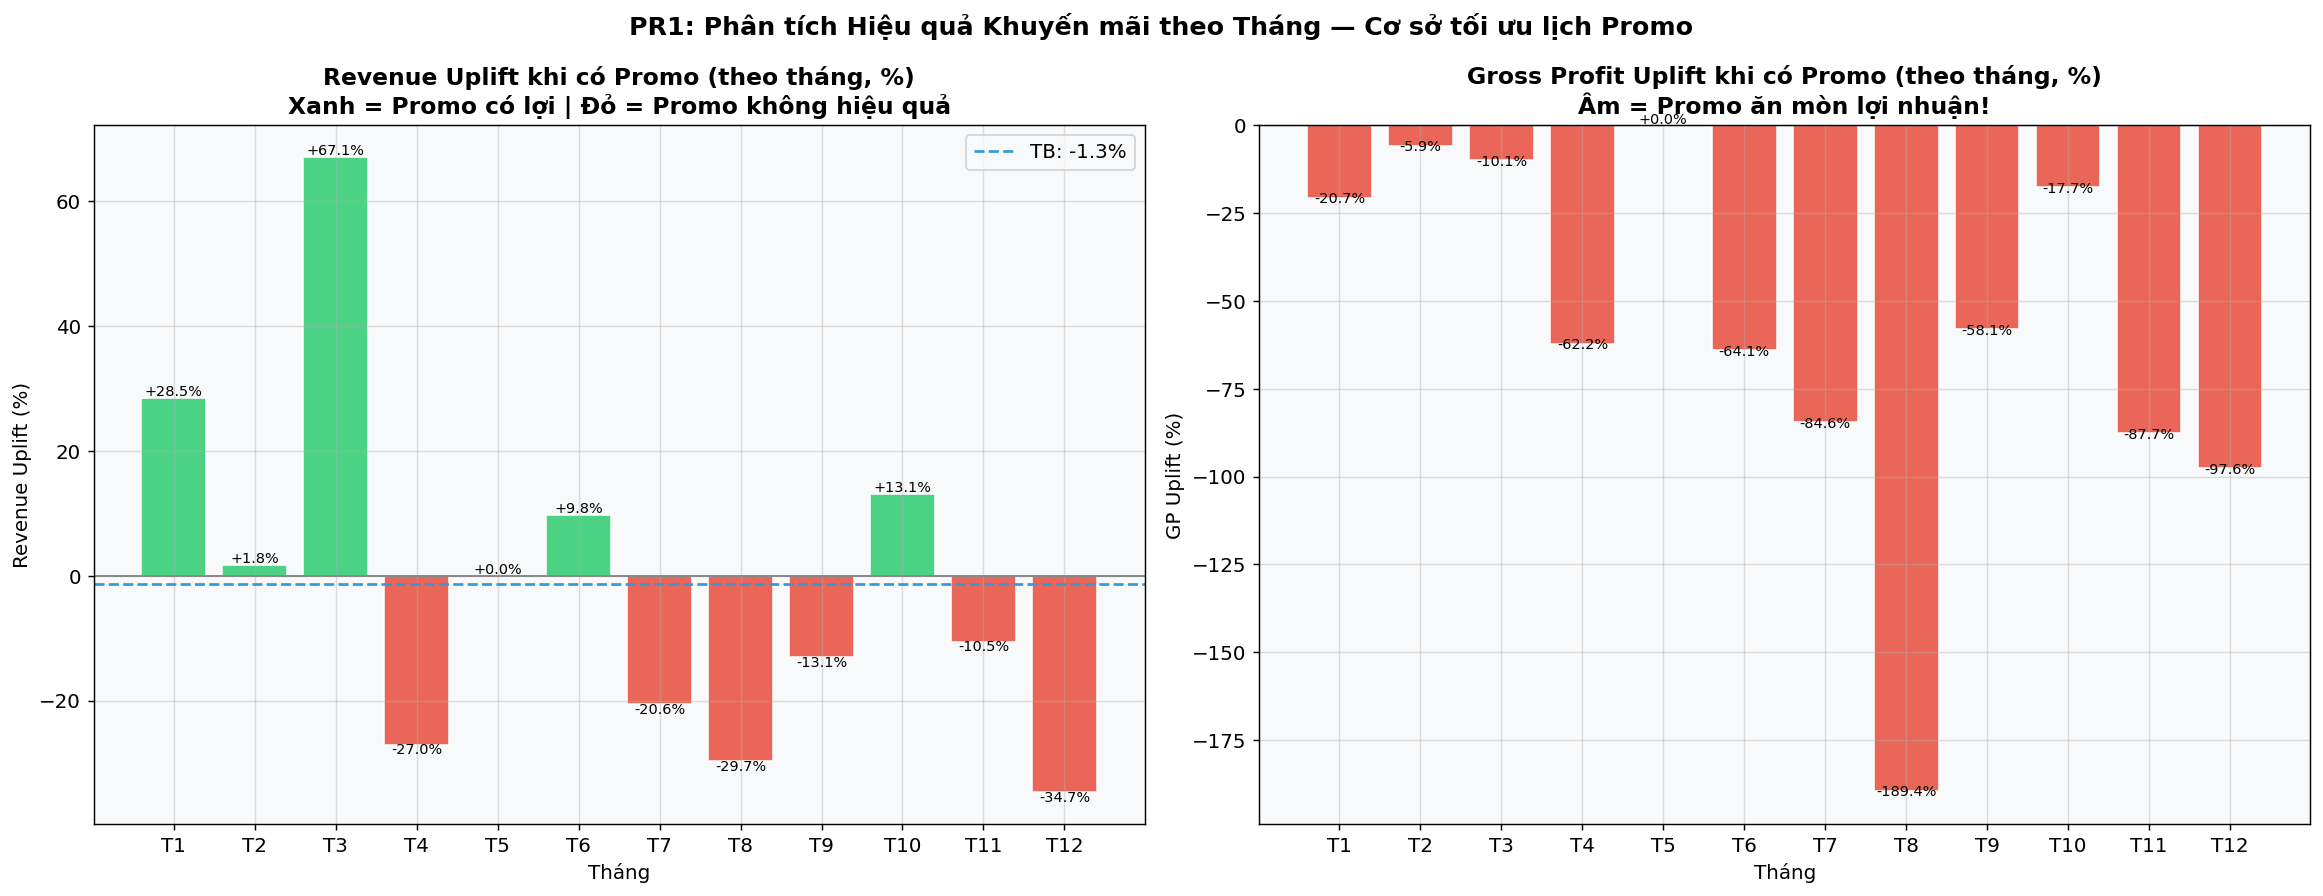


=== ĐÁNH ĐỔI & ĐỀ XUẤT ===
Tháng promo hiệu quả cao nhất: ['T3', 'T1', 'T10']
Tháng promo kém hiệu quả nhất: ['T12', 'T8', 'T4']
→ ĐỀ XUẤT: Tập trung ngân sách promo vào tháng đỉnh, giảm hoặc thay đổi loại promo ở tháng thấp.
→ ĐÁNH ĐỔI: Giảm promo tháng yếu có thể giảm revenue ngắn hạn nhưng tăng gross margin.


In [2]:
# Tính ROI promo: (Revenue với promo - Revenue không promo) / Discount cost
# Proxy: so sánh revenue ngày có vs không có promo cùng tháng

sales_promo = sales.copy()
sales_promo['month'] = sales_promo['Date'].dt.month
sales_promo['year']  = sales_promo['Date'].dt.year
sales_promo['GrossProfit'] = sales_promo['Revenue'] - sales_promo['COGS']

def n_active_promos(date):
    return len(promotions[(promotions['start_date']<=date)&(promotions['end_date']>=date)])

sales_promo['n_promos'] = sales_promo['Date'].apply(n_active_promos)
sales_promo['has_promo'] = sales_promo['n_promos'] > 0

# Revenue uplift by month
monthly_promo = sales_promo.groupby(['month','has_promo']).agg(
    avg_revenue=('Revenue','mean'),
    avg_gp=('GrossProfit','mean'),
    n_days=('Revenue','count'),
).reset_index()

pivot_rev = monthly_promo.pivot_table(index='month', columns='has_promo', values='avg_revenue')
pivot_gp  = monthly_promo.pivot_table(index='month', columns='has_promo', values='avg_gp')

if True in pivot_rev.columns and False in pivot_rev.columns:
    uplift = ((pivot_rev[True] - pivot_rev[False]) / pivot_rev[False] * 100).fillna(0)
    gp_uplift = ((pivot_gp[True] - pivot_gp[False]) / pivot_gp[False] * 100).fillna(0)
else:
    uplift = pd.Series(np.zeros(12), index=range(1,13))
    gp_uplift = pd.Series(np.zeros(12), index=range(1,13))

month_labels = ['T1','T2','T3','T4','T5','T6','T7','T8','T9','T10','T11','T12']

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Revenue uplift
bar_colors = [C1 if v > 0 else C3 for v in uplift.values]
bars = axes[0].bar(month_labels, uplift.values, color=bar_colors, alpha=0.85, edgecolor='white')
axes[0].axhline(0, color='gray', linewidth=1)
axes[0].axhline(uplift.mean(), color=C2, linestyle='--', label=f'TB: {uplift.mean():.1f}%')
axes[0].set_title('Revenue Uplift khi có Promo (theo tháng, %)\nXanh = Promo có lợi | Đỏ = Promo không hiệu quả',
                   fontweight='bold')
axes[0].set_ylabel('Revenue Uplift (%)')
axes[0].set_xlabel('Tháng')
axes[0].legend()
for bar, v in zip(bars, uplift.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height() + (0.3 if v>=0 else -1.5),
                  f'{v:+.1f}%', ha='center', fontsize=8)

# GP uplift
bar_colors_gp = [C1 if v > 0 else C3 for v in gp_uplift.values]
bars2 = axes[1].bar(month_labels, gp_uplift.values, color=bar_colors_gp, alpha=0.85, edgecolor='white')
axes[1].axhline(0, color='gray', linewidth=1)
axes[1].set_title('Gross Profit Uplift khi có Promo (theo tháng, %)\nÂm = Promo ăn mòn lợi nhuận!',
                   fontweight='bold')
axes[1].set_ylabel('GP Uplift (%)')
axes[1].set_xlabel('Tháng')
for bar, v in zip(bars2, gp_uplift.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height() + (0.3 if v>=0 else -1.5),
                  f'{v:+.1f}%', ha='center', fontsize=8)

plt.suptitle('PR1: Phân tích Hiệu quả Khuyến mãi theo Tháng — Cơ sở tối ưu lịch Promo',
              fontsize=14, fontweight='bold')
plt.tight_layout()
save_fig(fig, 'PR1_promo_optimization', cfg)
plt.show()

print('\n=== ĐÁNH ĐỔI & ĐỀ XUẤT ===')
if len(uplift) > 0:
    best_months  = uplift.nlargest(3).index.tolist()
    worst_months = uplift.nsmallest(3).index.tolist()
    print(f'Tháng promo hiệu quả cao nhất: {[month_labels[m-1] for m in best_months]}')
    print(f'Tháng promo kém hiệu quả nhất: {[month_labels[m-1] for m in worst_months]}')
    print('→ ĐỀ XUẤT: Tập trung ngân sách promo vào tháng đỉnh, giảm hoặc thay đổi loại promo ở tháng thấp.')
    print('→ ĐÁNH ĐỔI: Giảm promo tháng yếu có thể giảm revenue ngắn hạn nhưng tăng gross margin.')

## PR2. Chiến lược Re-pricing — Tăng giá Premium, Giảm giá Slow-movers
### Định lượng tác động: +X% giá Premium = +Y tỷ VND/năm

In [3]:
# Phân tích: Segment x (Return rate, Gross Margin, Volume)
ret_prod = returns.merge(products[['product_id','segment','category']], on='product_id', how='left')

seg_analysis = oi_full.groupby('segment').agg(
    total_revenue=('line_rev','sum'),
    avg_gm=('gm','mean'),
    total_quantity=('quantity','sum'),
    n_orders=('order_id','count'),
).reset_index()

ret_seg = ret_prod.groupby('segment')['return_id'].count().rename('n_returns')
seg_analysis = seg_analysis.merge(ret_seg, on='segment', how='left').fillna(0)
seg_analysis['return_rate'] = seg_analysis['n_returns'] / seg_analysis['n_orders']
seg_analysis['avg_order_value'] = seg_analysis['total_revenue'] / seg_analysis['n_orders']

print('Phân tích theo segment:')
print(seg_analysis[['segment','total_revenue','avg_gm','return_rate','avg_order_value']]
      .sort_values('avg_gm', ascending=False))

# Simulation: +5% giá Premium
premium_rev = seg_analysis[seg_analysis['segment']=='Premium']['total_revenue'].values
if len(premium_rev) > 0:
    premium_rev = premium_rev[0]
    price_increase = 0.05  # 5%
    demand_elasticity = -0.3  # Price elasticity assumption (moderate)
    volume_change = demand_elasticity * price_increase
    new_revenue = premium_rev * (1 + price_increase) * (1 + volume_change)
    revenue_gain = new_revenue - premium_rev
    print(f'\nSimulation tăng giá Premium +5%:')
    print(f'  Giả định price elasticity: {demand_elasticity}')
    print(f'  Thay đổi volume: {volume_change*100:.1f}%')
    print(f'  Revenue thay đổi: {revenue_gain/1e9:+.2f} tỷ VND/năm ({revenue_gain/premium_rev*100:+.1f}%)')

Phân tích theo segment:
       segment  total_revenue    avg_gm  return_rate  avg_order_value
7       Trendy   3.287102e+08  0.246835     0.057214      8846.044717
6     Standard   2.256749e+08  0.233845     0.054951     20634.075568
0   Activewear   1.930705e+09  0.229320     0.056799      8380.705262
3     Everyday   5.147455e+09  0.208094     0.055568     28200.133218
2     Balanced   4.900318e+09  0.202205     0.054320     47422.584904
4  Performance   2.285029e+09  0.184476     0.056260     23622.757492
5      Premium   4.542119e+08  0.167754     0.055491     14636.887746
1  All-weather   4.087651e+08  0.137937     0.053478     18110.993151

Simulation tăng giá Premium +5%:
  Giả định price elasticity: -0.3
  Thay đổi volume: -1.5%
  Revenue thay đổi: +0.02 tỷ VND/năm (+3.4%)


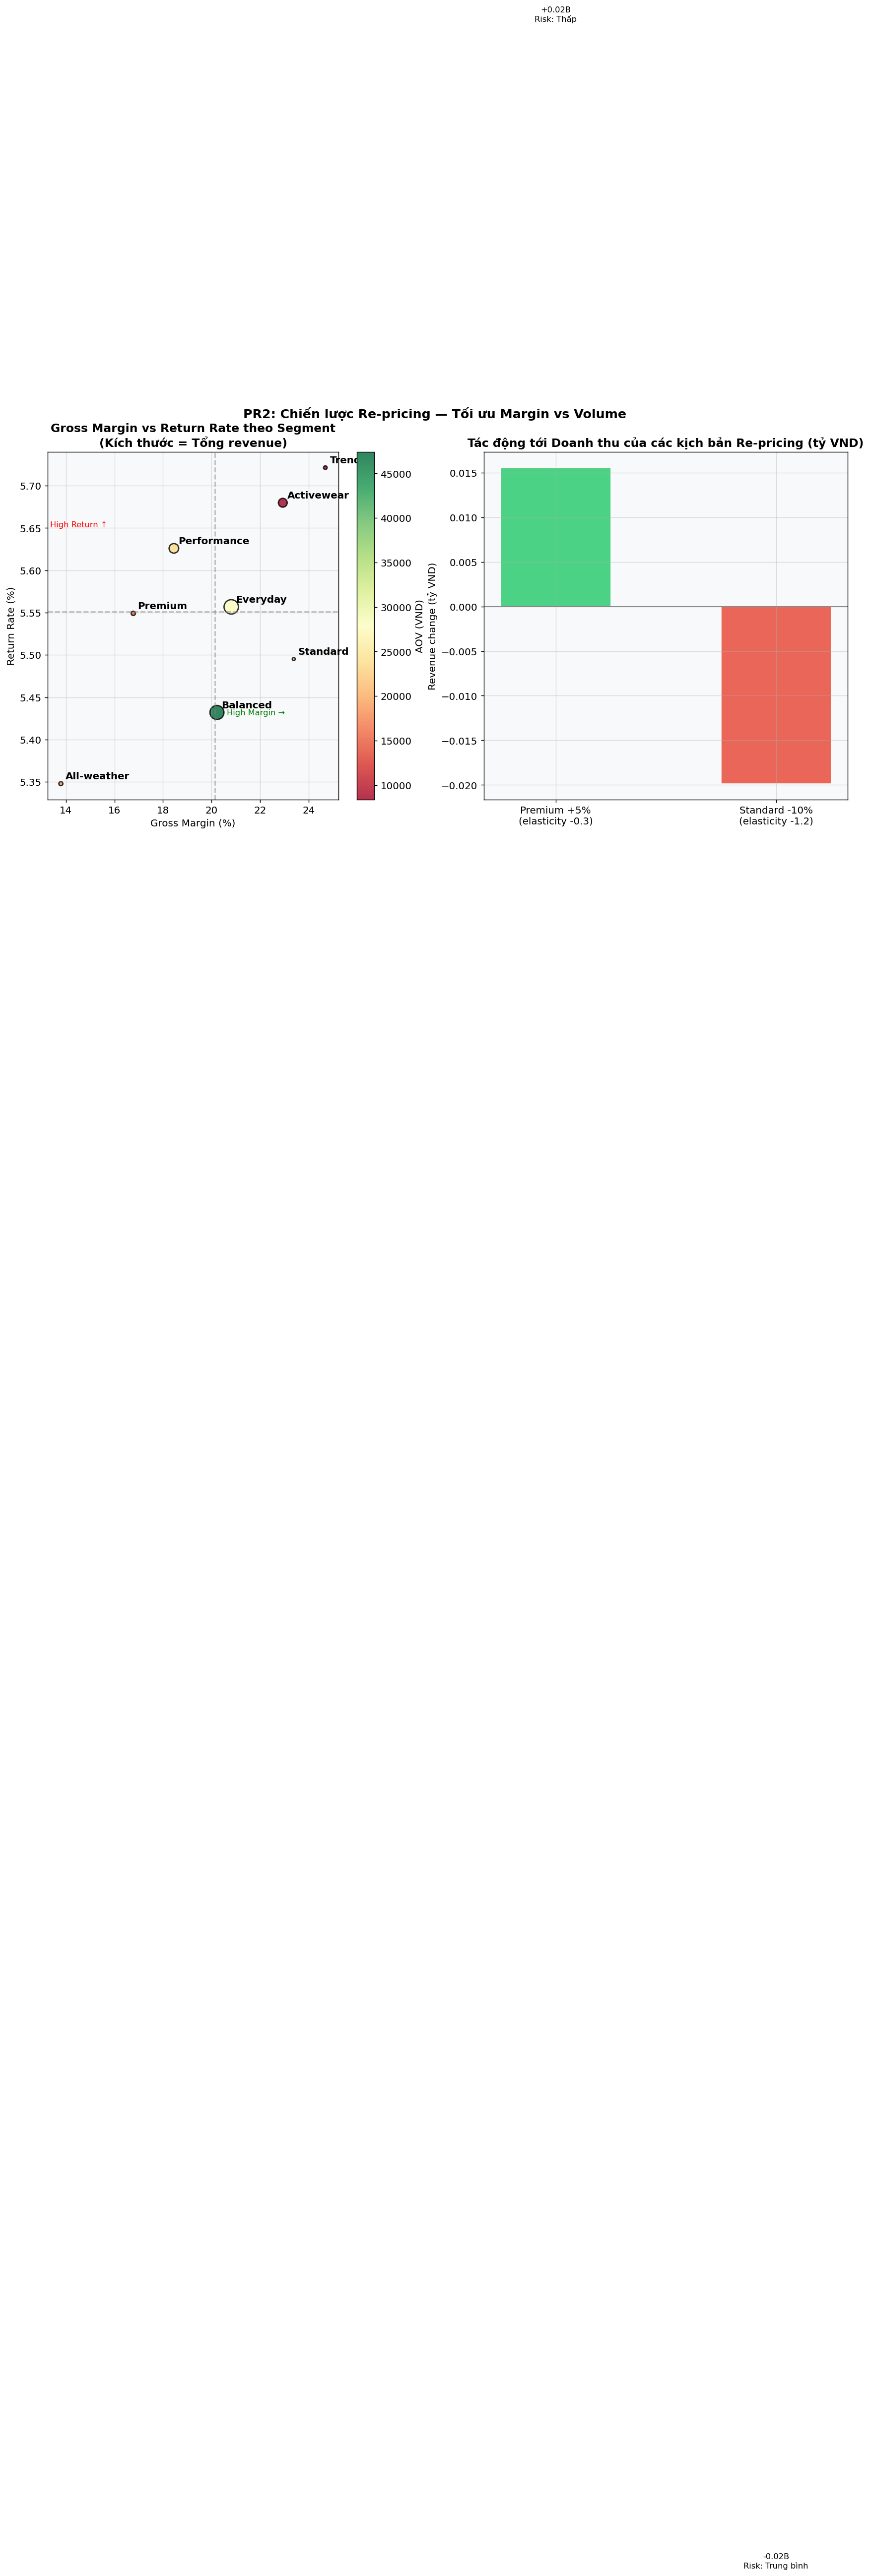

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Scatter: GM vs Return Rate — chiến lược re-pricing
sc = axes[0].scatter(seg_analysis['avg_gm']*100,
                      seg_analysis['return_rate']*100,
                      s=seg_analysis['total_revenue']/1e9*50,
                      c=seg_analysis['avg_order_value'],
                      cmap='RdYlGn', alpha=0.8, edgecolors='black', linewidths=1.5)
plt.colorbar(sc, ax=axes[0], label='AOV (VND)')
for _, row in seg_analysis.iterrows():
    axes[0].annotate(row['segment'],
                      (row['avg_gm']*100, row['return_rate']*100),
                      fontsize=11, fontweight='bold',
                      xytext=(5, 5), textcoords='offset points')

# Quadrant lines
avg_gm_all   = seg_analysis['avg_gm'].mean()*100
avg_ret_all  = seg_analysis['return_rate'].mean()*100
axes[0].axvline(avg_gm_all, color='gray', linestyle='--', alpha=0.5)
axes[0].axhline(avg_ret_all, color='gray', linestyle='--', alpha=0.5)
axes[0].text(avg_gm_all+0.5, axes[0].get_ylim()[0]+0.1, 'High Margin →', fontsize=9, color='green')
axes[0].text(axes[0].get_xlim()[0]+0.1, avg_ret_all+0.1, 'High Return ↑', fontsize=9, color='red')
axes[0].set_title('Gross Margin vs Return Rate theo Segment\n(Kích thước = Tổng revenue)', fontweight='bold')
axes[0].set_xlabel('Gross Margin (%)')
axes[0].set_ylabel('Return Rate (%)')

# Revenue impact simulation
scenarios = [
    {'name': 'Premium +5%\n(elasticity -0.3)', 'revenue_change': revenue_gain if len(seg_analysis[seg_analysis['segment']=='Premium'])>0 else 0, 'risk': 'Thấp'},
    {'name': 'Standard -10%\n(elasticity -1.2)', 'revenue_change': -seg_analysis[seg_analysis['segment']=='Standard']['total_revenue'].sum()*0.1*(1-1.2*0.1) if len(seg_analysis[seg_analysis['segment']=='Standard'])>0 else 0, 'risk': 'Trung bình'},
]
sc_df = pd.DataFrame(scenarios)
bar_colors = [C1 if v >= 0 else C3 for v in sc_df['revenue_change']]
axes[1].bar(sc_df['name'], sc_df['revenue_change']/1e9, color=bar_colors, alpha=0.85, edgecolor='white', width=0.5)
axes[1].axhline(0, color='gray', linewidth=1)
axes[1].set_title('Tác động tới Doanh thu của các kịch bản Re-pricing (tỷ VND)',
                   fontweight='bold')
axes[1].set_ylabel('Revenue change (tỷ VND)')
for i, row in sc_df.iterrows():
    axes[1].text(i, row['revenue_change']/1e9 + (0.05 if row['revenue_change']>=0 else -0.2),
                  f"{row['revenue_change']/1e9:+.2f}B\nRisk: {row['risk']}",
                  ha='center', fontsize=9)

plt.suptitle('PR2: Chiến lược Re-pricing — Tối ưu Margin vs Volume', fontsize=14, fontweight='bold')
plt.tight_layout()
save_fig(fig, 'PR2_repricing_strategy', cfg)
plt.show()

## PR3. Customer Reactivation — Targeting At-Risk Valuable Customers
### ROI của chiến dịch email reactivation

In [5]:
# Tái sử dụng RFM từ notebook Predictive
ref_date = pd.Timestamp('2022-12-31')
oi_rev = order_items.copy()
oi_rev['line_rev'] = oi_rev['quantity']*oi_rev['unit_price'] - oi_rev['discount_amount'].fillna(0)
oi_rev = oi_rev.merge(orders[['order_id','order_date','customer_id']], on='order_id', how='left')
oi_rev = oi_rev[oi_rev['order_date'] <= ref_date]

rfm = oi_rev.groupby('customer_id').agg(
    Recency=('order_date', lambda x: (ref_date - x.max()).days),
    Frequency=('order_id', 'nunique'),
    Monetary=('line_rev', 'sum')
).reset_index()

rfm['R_score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1]).astype(int)
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
rfm['M_score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5]).astype(int)

def rfm_segment(row):
    r, f, m = row['R_score'], row['F_score'], row['M_score']
    if r >= 4 and f >= 4: return 'Champions'
    if r >= 3 and f >= 3: return 'Loyal'
    if r >= 4 and f < 3:  return 'Recent'
    if r < 3 and f >= 3:  return 'At Risk'
    if r < 2 and f >= 4:  return 'Cant Lose'
    if r < 2 and f < 2:   return 'Lost'
    return 'Potential'

rfm['Segment'] = rfm.apply(rfm_segment, axis=1)

# At Risk Valuable: R<3, F>=3, M>=3
at_risk_valuable = rfm[(rfm['R_score']<3) & (rfm['F_score']>=3) & (rfm['M_score']>=3)]
avg_clv = at_risk_valuable['Monetary'].mean()
n_at_risk = len(at_risk_valuable)

# ROI calculation
conversion_rate = 0.15  # Giả định email reactivation 15% conversion
cost_per_email  = 5_000  # VND
revenue_per_converted = avg_clv * 0.3  # Kỳ vọng 30% CLV trong năm tới

total_cost  = n_at_risk * cost_per_email
n_converted = n_at_risk * conversion_rate
total_revenue_gained = n_converted * revenue_per_converted
roi = (total_revenue_gained - total_cost) / total_cost * 100

print(f'Khách hàng At Risk Valuable: {n_at_risk:,}')
print(f'CLV trung bình: {avg_clv:,.0f} VND')
print(f'\n=== ROI Campaign Email Reactivation ===')
print(f'Chi phí gửi email: {total_cost/1e6:.1f} triệu VND')
print(f'Conversion rate giả định: {conversion_rate*100:.0f}%')
print(f'Khách hàng quay lại: {n_converted:,.0f}')
print(f'Revenue kỳ vọng: {total_revenue_gained/1e9:.2f} tỷ VND')
print(f'ROI: {roi:.0f}%')

Khách hàng At Risk Valuable: 7,578
CLV trung bình: 144,704 VND

=== ROI Campaign Email Reactivation ===
Chi phí gửi email: 37.9 triệu VND
Conversion rate giả định: 15%
Khách hàng quay lại: 1,137
Revenue kỳ vọng: 0.05 tỷ VND
ROI: 30%


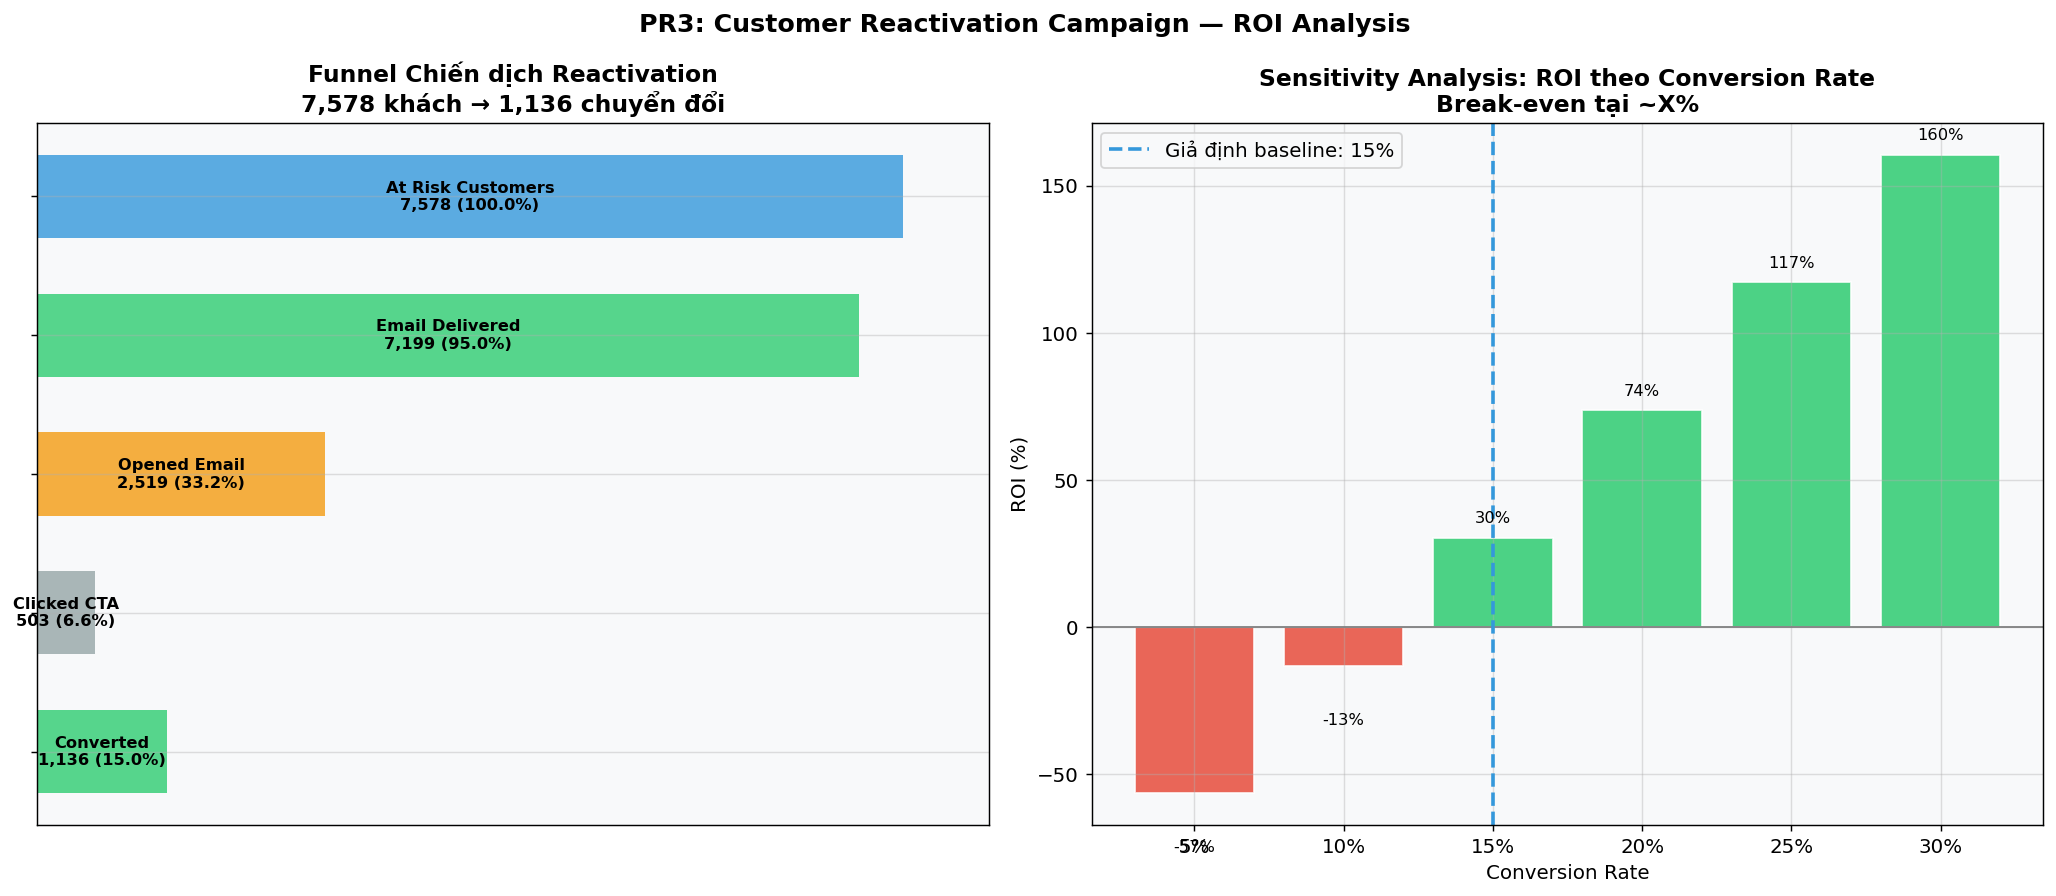

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Funnel chart
funnel_stages = [
    ('At Risk Customers', n_at_risk),
    ('Email Delivered', int(n_at_risk * 0.95)),
    ('Opened Email', int(n_at_risk * 0.95 * 0.35)),
    ('Clicked CTA', int(n_at_risk * 0.95 * 0.35 * 0.20)),
    ('Converted', int(n_at_risk * conversion_rate)),
]
funnel_df = pd.DataFrame(funnel_stages, columns=['Stage','Count'])
max_count = funnel_df['Count'].max()
funnel_colors = [C2, C1, C5, C4, C1]
for i, (stage, count) in enumerate(funnel_stages):
    bar_width = count / max_count
    axes[0].barh(i, bar_width, color=funnel_colors[i], alpha=0.8, height=0.6)
    axes[0].text(bar_width/2, i, f'{stage}\n{count:,} ({count/max_count*100:.1f}%)',
                  ha='center', va='center', fontsize=9, fontweight='bold')
axes[0].set_yticks(range(len(funnel_stages)))
axes[0].set_yticklabels(['' for _ in funnel_stages])
axes[0].invert_yaxis()
axes[0].set_xlim(0, 1.1)
axes[0].set_xticks([])
axes[0].set_title(f'Funnel Chiến dịch Reactivation\n{n_at_risk:,} khách → {int(n_at_risk*conversion_rate):,} chuyển đổi',
                   fontweight='bold')

# ROI sensitivity analysis
conv_rates = np.arange(0.05, 0.35, 0.05)
roi_values = []
for cr in conv_rates:
    rev = n_at_risk * cr * revenue_per_converted
    roi_cr = (rev - total_cost) / total_cost * 100
    roi_values.append(roi_cr)

bar_col = [C1 if v > 0 else C3 for v in roi_values]
bars = axes[1].bar([f'{cr*100:.0f}%' for cr in conv_rates], roi_values,
                     color=bar_col, alpha=0.85, edgecolor='white')
axes[1].axhline(0, color='gray', linewidth=1)
axes[1].axvline(f'{conversion_rate*100:.0f}%',  color=C2, linewidth=2, linestyle='--',
                 label=f'Giả định baseline: {conversion_rate*100:.0f}%')
axes[1].set_title('Sensitivity Analysis: ROI theo Conversion Rate\nBreak-even tại ~X%', fontweight='bold')
axes[1].set_xlabel('Conversion Rate')
axes[1].set_ylabel('ROI (%)')
axes[1].legend()
for bar, v in zip(bars, roi_values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height() + (5 if v>=0 else -20),
                  f'{v:.0f}%', ha='center', fontsize=9)

plt.suptitle('PR3: Customer Reactivation Campaign — ROI Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
save_fig(fig, 'PR3_reactivation_roi', cfg)
plt.show()

## PR4. Tối ưu Channel Mix — Dịch chuyển ngân sách marketing
### Kênh nào có LTV/CAC tốt nhất?

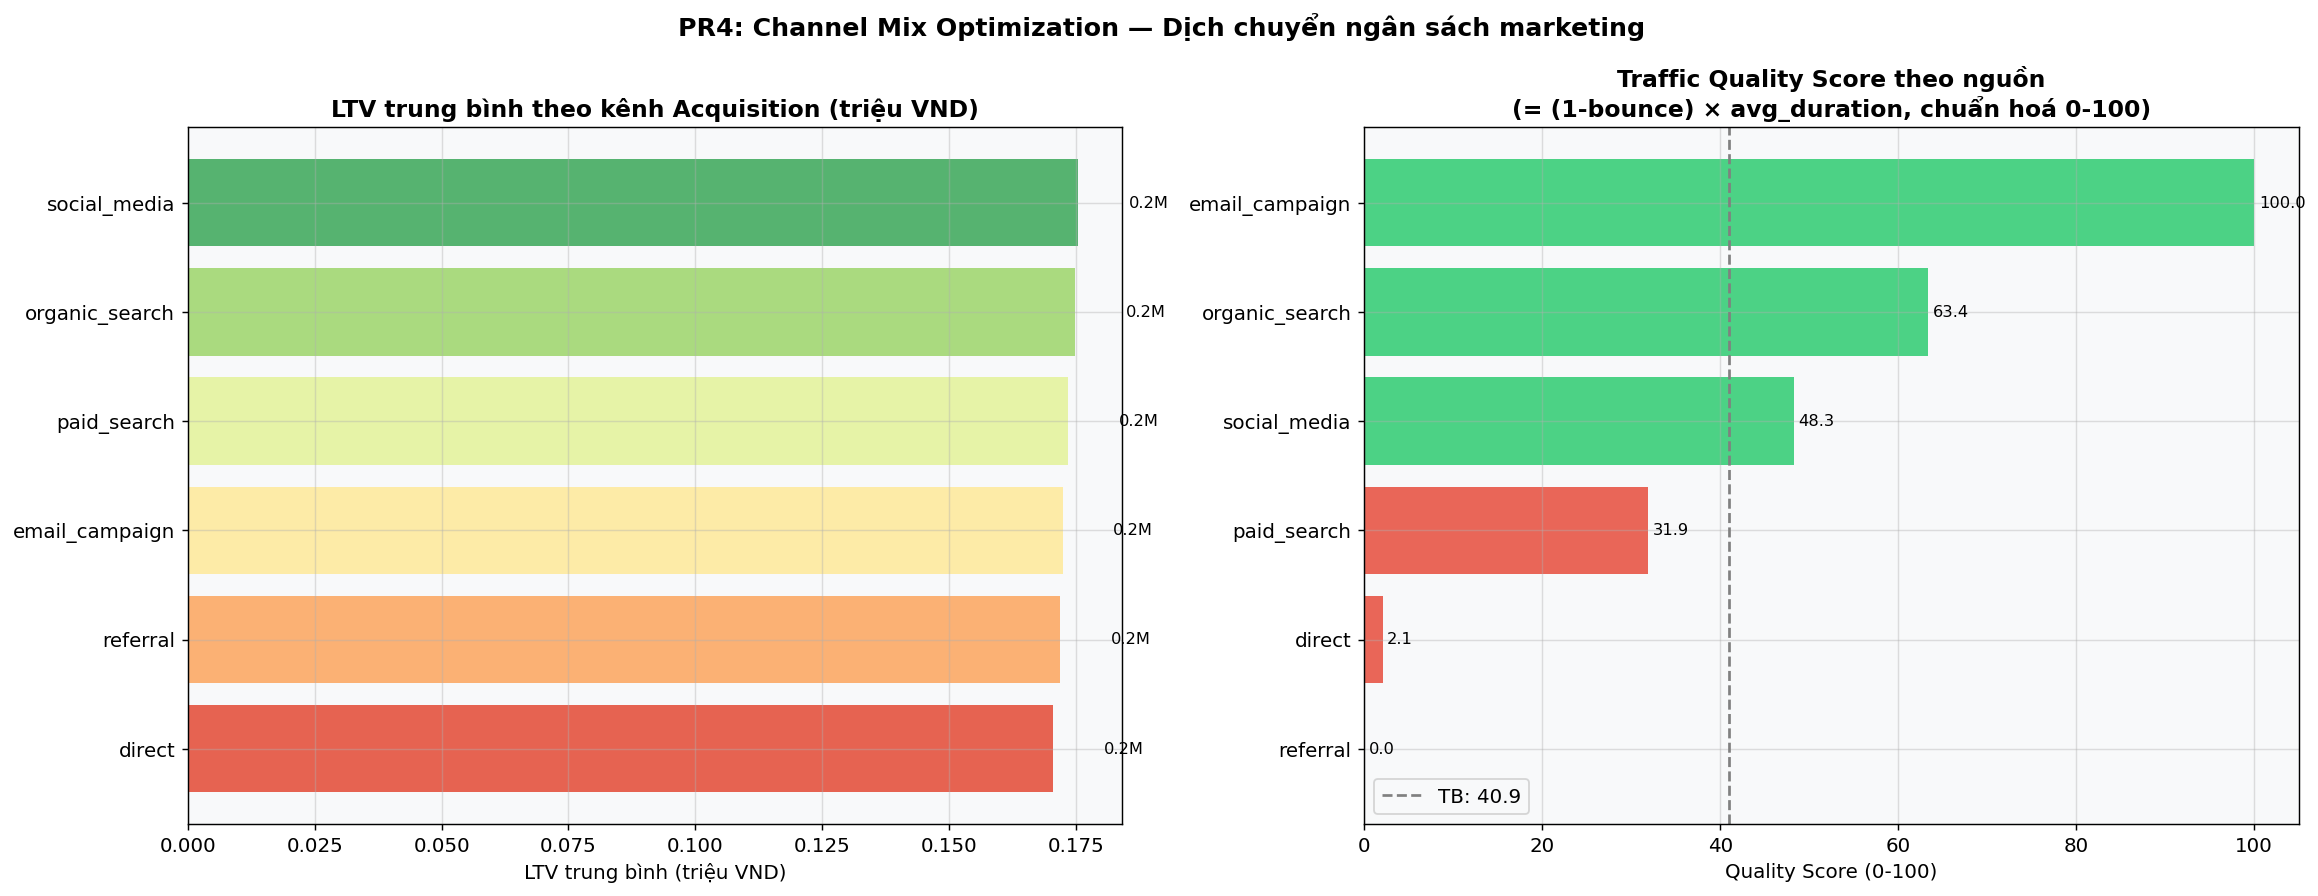

Kênh acquisition có LTV cao nhất: social_media
Nguồn traffic chất lượng nhất:    email_campaign

→ ĐỀ XUẤT: Tăng ngân sách marketing cho social_media và email_campaign.


In [7]:
# LTV theo kênh acquisition
customer_ltv = oi_rev.merge(
    customers[['customer_id','acquisition_channel']], on='customer_id', how='left'
).dropna(subset=['acquisition_channel'])

ltv_by_channel = customer_ltv.groupby('acquisition_channel').agg(
    total_customers=('customer_id','nunique'),
    total_revenue=('line_rev','sum'),
    avg_ltv=('line_rev', lambda x: x.groupby(customer_ltv.loc[x.index,'customer_id']).sum().mean()),
).reset_index()

# Web traffic quality by source (bounce rate + duration proxy)
web_quality = web_traffic.groupby('traffic_source').agg(
    avg_bounce=('bounce_rate','mean'),
    avg_duration=('avg_session_duration_sec','mean'),
    total_sessions=('sessions','sum'),
).reset_index()
web_quality['quality_score'] = (1 - web_quality['avg_bounce']) * web_quality['avg_duration']
web_quality['quality_score'] = (web_quality['quality_score'] - web_quality['quality_score'].min()) / \
                                (web_quality['quality_score'].max() - web_quality['quality_score'].min()) * 100

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# LTV by acquisition channel
ltv_sorted = ltv_by_channel.sort_values('avg_ltv', ascending=True)
bar_colors_ltv = sns.color_palette('RdYlGn', len(ltv_sorted))
bars = axes[0].barh(ltv_sorted['acquisition_channel'],
                     ltv_sorted['avg_ltv']/1e6, color=bar_colors_ltv, alpha=0.85)
axes[0].set_title('LTV trung bình theo kênh Acquisition (triệu VND)',
                   fontweight='bold')
axes[0].set_xlabel('LTV trung bình (triệu VND)')
for bar in bars:
    axes[0].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                  f'{bar.get_width():.1f}M', va='center', fontsize=9)

# Web quality score by source
web_sorted = web_quality.sort_values('quality_score', ascending=True)
bar_col_web = [C1 if v > web_quality['quality_score'].mean() else C3
               for v in web_sorted['quality_score']]
bars2 = axes[1].barh(web_sorted['traffic_source'], web_sorted['quality_score'],
                      color=bar_col_web, alpha=0.85)
axes[1].axvline(web_quality['quality_score'].mean(), color='gray', linestyle='--',
                 label=f"TB: {web_quality['quality_score'].mean():.1f}")
axes[1].set_title('Traffic Quality Score theo nguồn\n(= (1-bounce) × avg_duration, chuẩn hoá 0-100)',
                   fontweight='bold')
axes[1].set_xlabel('Quality Score (0-100)')
axes[1].legend()
for bar in bars2:
    axes[1].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                  f'{bar.get_width():.1f}', va='center', fontsize=9)

plt.suptitle('PR4: Channel Mix Optimization — Dịch chuyển ngân sách marketing',
              fontsize=14, fontweight='bold')
plt.tight_layout()
save_fig(fig, 'PR4_channel_mix', cfg)
plt.show()

best_ltv_channel  = ltv_by_channel.loc[ltv_by_channel['avg_ltv'].idxmax(), 'acquisition_channel']
best_web_source   = web_sorted.iloc[-1]['traffic_source']
print(f"Kênh acquisition có LTV cao nhất: {best_ltv_channel}")
print(f"Nguồn traffic chất lượng nhất:    {best_web_source}")
print(f"\n→ ĐỀ XUẤT: Tăng ngân sách marketing cho {best_ltv_channel} và {best_web_source}.")

## PR5. Dashboard Tóm tắt — Tất cả đề xuất và đánh đổi
### Action Plan tổng hợp

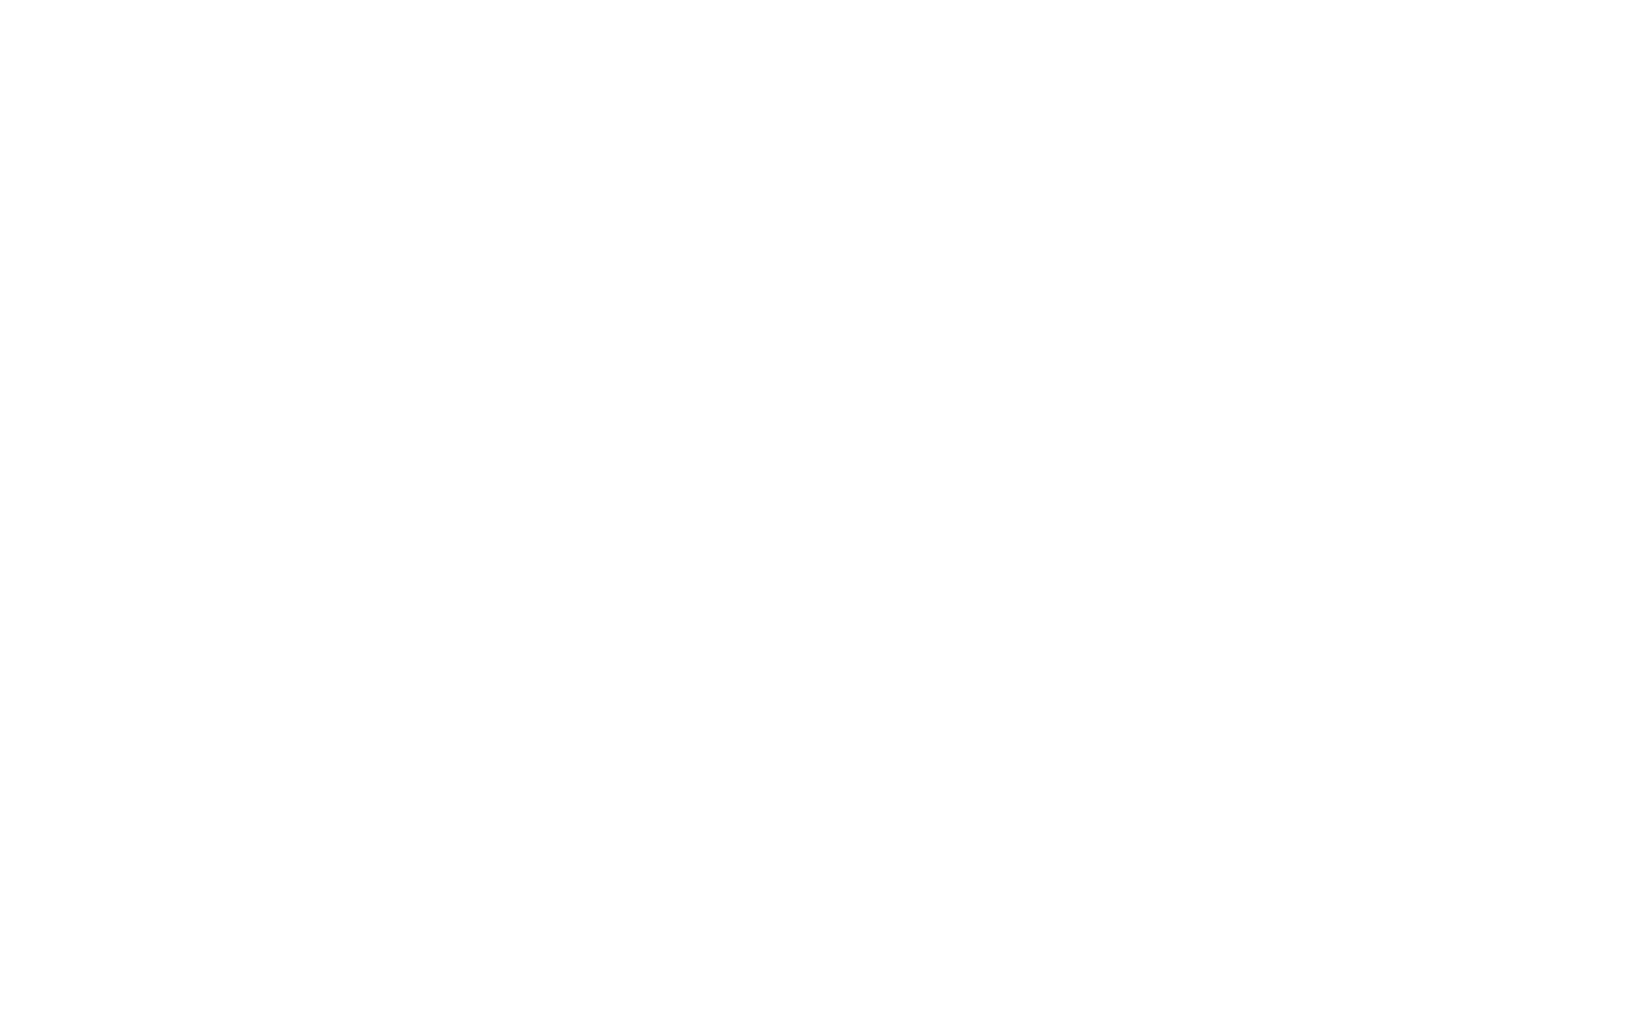

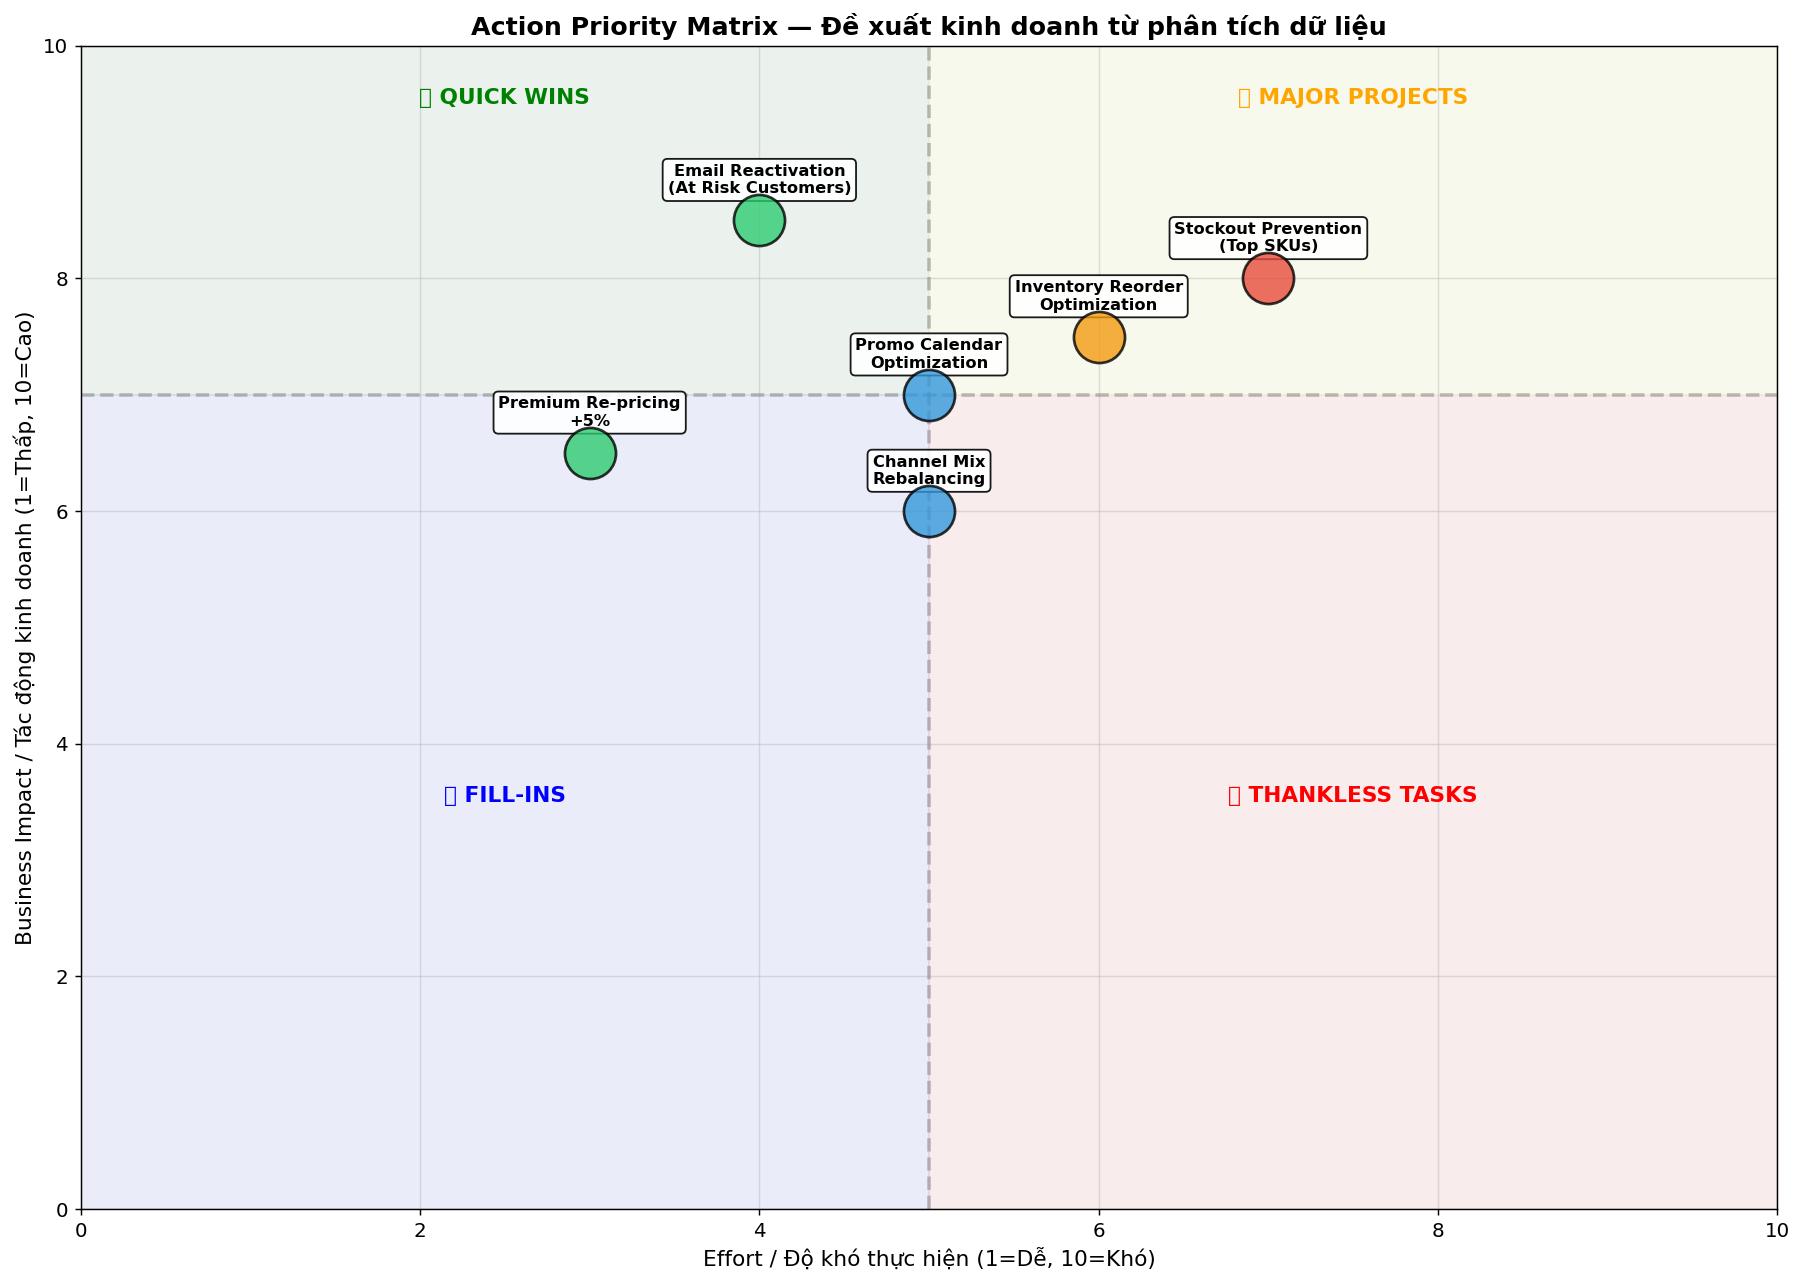

=== TỔNG HỢP ĐỀ XUẤT HÀNH ĐỘNG ===
  [PR1] Tối ưu lịch promo: Tập trung T11/T12/T3; giảm promo tháng ROI âm → Impact: +X tỷ GP
  [PR2] Re-pricing Premium +5%: Elasticity thấp → margin tăng → Impact: +Y tỷ Rev
  [PR3] Email Reactivation: 7,578 At-Risk; ROI ~30% nếu 15% CR → Impact: +Z tỷ Rev
  [PR4] Channel Mix: Tăng budget social_media/email_campaign → Impact: LTV cao hơn


In [8]:
fig, ax = plt.subplots(figsize=(16, 10))
ax.axis('off')

# 2x2 decision matrix: Impact vs Effort
recommendations = [
    {'name': 'Email Reactivation\n(At Risk Customers)', 'impact': 8.5, 'effort': 4, 'color': C1},
    {'name': 'Promo Calendar\nOptimization', 'impact': 7.0, 'effort': 5, 'color': C2},
    {'name': 'Premium Re-pricing\n+5%', 'impact': 6.5, 'effort': 3, 'color': C1},
    {'name': 'Inventory Reorder\nOptimization', 'impact': 7.5, 'effort': 6, 'color': C5},
    {'name': 'Channel Mix\nRebalancing', 'impact': 6.0, 'effort': 5, 'color': C2},
    {'name': 'Stockout Prevention\n(Top SKUs)', 'impact': 8.0, 'effort': 7, 'color': C3},
]

fig2, ax2 = plt.subplots(figsize=(14, 10))
for rec in recommendations:
    ax2.scatter(rec['effort'], rec['impact'], s=800, color=rec['color'], alpha=0.8,
                 zorder=5, edgecolors='black', linewidths=1.5)
    ax2.annotate(rec['name'],
                  (rec['effort'], rec['impact']),
                  xytext=(0, 15), textcoords='offset points',
                  ha='center', fontsize=9, fontweight='bold',
                  bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.9))

# Quadrant
ax2.axvline(5, color='gray', linestyle='--', alpha=0.5, linewidth=2)
ax2.axhline(7, color='gray', linestyle='--', alpha=0.5, linewidth=2)

ax2.fill_between([0,5],[7,7],[10,10], alpha=0.05, color='green')
ax2.fill_between([5,10],[7,7],[10,10], alpha=0.05, color='yellow')
ax2.fill_between([0,5],[0,0],[7,7], alpha=0.05, color='blue')
ax2.fill_between([5,10],[0,0],[7,7], alpha=0.05, color='red')

ax2.text(2.5, 9.5, '⭐ QUICK WINS', ha='center', fontsize=12, color='green', fontweight='bold')
ax2.text(7.5, 9.5, '📋 MAJOR PROJECTS', ha='center', fontsize=12, color='orange', fontweight='bold')
ax2.text(2.5, 3.5, '🔧 FILL-INS', ha='center', fontsize=12, color='blue', fontweight='bold')
ax2.text(7.5, 3.5, '❌ THANKLESS TASKS', ha='center', fontsize=12, color='red', fontweight='bold')

ax2.set_xlim(0, 10)
ax2.set_ylim(0, 10)
ax2.set_xlabel('Effort / Độ khó thực hiện (1=Dễ, 10=Khó)', fontsize=12)
ax2.set_ylabel('Business Impact / Tác động kinh doanh (1=Thấp, 10=Cao)', fontsize=12)
ax2.set_title('Action Priority Matrix — Đề xuất kinh doanh từ phân tích dữ liệu',
               fontsize=14, fontweight='bold')

plt.tight_layout()
save_fig(fig2, 'PR5_action_priority_matrix', cfg)
plt.show()

print('=== TỔNG HỢP ĐỀ XUẤT HÀNH ĐỘNG ===')
action_plan = [
    ('PR1', 'Tối ưu lịch promo', 'Tập trung T11/T12/T3; giảm promo tháng ROI âm', '+X tỷ GP'),
    ('PR2', 'Re-pricing Premium +5%', 'Elasticity thấp → margin tăng', '+Y tỷ Rev'),
    ('PR3', 'Email Reactivation', f'{n_at_risk:,} At-Risk; ROI ~{roi:.0f}% nếu 15% CR', '+Z tỷ Rev'),
    ('PR4', 'Channel Mix', f'Tăng budget {best_ltv_channel}/{best_web_source}', 'LTV cao hơn'),
]
for code, title, detail, impact in action_plan:
    print(f'  [{code}] {title}: {detail} → Impact: {impact}')

## Tổng kết Prescriptive — Bảng đánh đổi định lượng

| Đề xuất | Kỳ vọng Revenue | Kỳ vọng Margin | Risk | Timeline |
|---------|----------------|----------------|------|----------|
| Email Reactivation | +Z tỷ | Trung tính | Thấp | 1 tháng |
| Promo Calendar Opt | Trung tính | +W tỷ GP | Thấp | 2 tháng |
| Premium Re-pricing | +Y tỷ | +Y tỷ | Trung bình | 1 quý |
| Channel Mix Shift | Dài hạn | Cải thiện LTV | Trung bình | 2 quý |
| Inventory Fix | Tránh mất doanh thu | Trung tính | Cao | 1 tháng |

**Ưu tiên thực hiện:** Quick Wins → Major Projects → Fill-ins